In [18]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

In [19]:
df = pd.DataFrame(json.load(open('Sriharsha Spotify Account Data/StreamingHistory_music_0.json', encoding='utf-8')) + json.load(open('Sriharsha Spotify Account Data/StreamingHistory_music_1.json', encoding='utf-8')))
df.head()
df.columns
df.info()
df.describe()
plt.rcParams['font.family'] = ['Arial', 'MS Gothic']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10672 entries, 0 to 10671
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   endTime     10672 non-null  object
 1   artistName  10672 non-null  object
 2   trackName   10672 non-null  object
 3   msPlayed    10672 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 333.6+ KB


In [20]:
df = df[df['msPlayed'] > 5000]
df['endTime'] = pd.to_datetime(df['endTime'], utc=True)
df['endTime'] = df['endTime'].dt.tz_convert('America/Chicago')
df['minutes'] = df['msPlayed'] / 60000
df['hour'] = df['endTime'].dt.hour
df['day'] = df['endTime'].dt.day_name()
df['month'] = df['endTime'].dt.to_period('M')

C:\Users\sriha\AppData\Local\Temp\ipykernel_9528\72139736.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['endTime'].dt.to_period('M')


In [21]:
totalmin = df['minutes'].sum()
totalhr = totalmin / 60
totalstreams = len(df)
uniqueartists = df['artistName'].nunique()
uniquetracks = df['trackName'].nunique()
dailygroup = df.groupby(df['endTime'].dt.date)['minutes'].sum()
avgdaily = dailygroup.mean()
meddaily = dailygroup.median()
stddaily = dailygroup.std()
maxday = dailygroup.max()
topartistmins = df.groupby('artistName')['minutes'].sum().max()
toptrackmins = df.groupby('trackName')['minutes'].sum().max()
print(f"Total Listening: {totalmin:,.1f} mins ({totalhr:,.1f} hours)")
print(f"Total Streams: {totalstreams:,}")
print(f"Unique Artists: {uniqueartists:,}")
print(f"Unique Tracks: {uniquetracks:,}")
print(f"Daily Average: {avgdaily:,.1f} mins")
print(f"Daily Median: {meddaily:,.1f} mins")
print(f"Daily Std Dev: {stddaily:,.1f} mins")
print(f"Max Daily Minutes: {maxday:,.1f} mins")
print(f"Top Artist Minutes: {topartistmins:,.1f} mins")
print(f"Top Track Minutes: {toptrackmins:,.1f} mins")

Total Listening: 30,391.4 mins (506.5 hours)
Total Streams: 10,422
Unique Artists: 775
Unique Tracks: 2,858
Daily Average: 103.7 mins
Daily Median: 89.9 mins
Daily Std Dev: 79.8 mins
Max Daily Minutes: 530.7 mins
Top Artist Minutes: 1,627.5 mins
Top Track Minutes: 192.1 mins


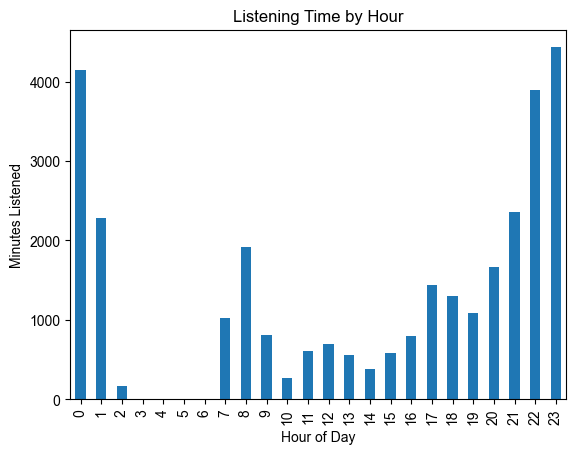

In [22]:
hours = df.groupby('hour')['minutes'].sum().reindex(range(24), fill_value=0)
hours.plot(kind='bar')
plt.title("Listening Time by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Minutes Listened")
plt.show()

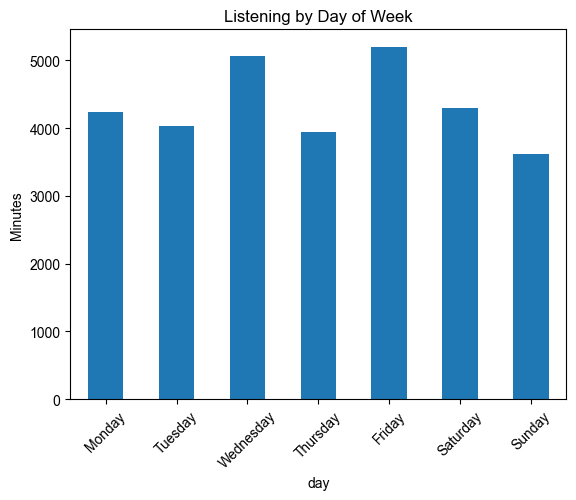

In [23]:
df.groupby('day')['minutes'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(kind='bar')
plt.title("Listening by Day of Week")
plt.ylabel("Minutes")
plt.xticks(rotation=45)
plt.show()

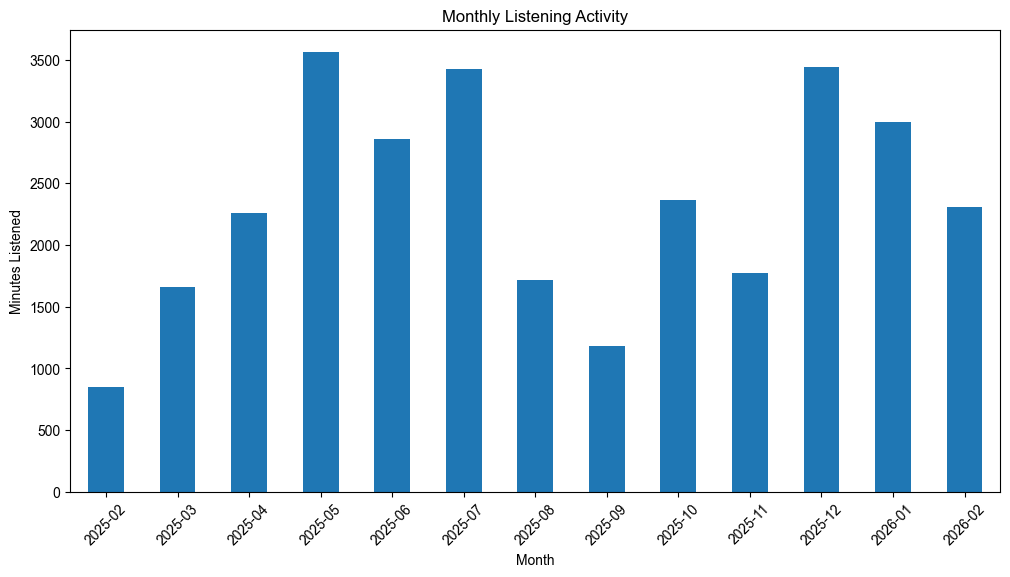

In [24]:
monthlytrend = df.groupby('month')['minutes'].sum()
plt.figure(figsize=(12, 6))
monthlytrend.plot(kind='bar')
plt.title('Monthly Listening Activity')
plt.xlabel('Month')
plt.ylabel('Minutes Listened')
plt.xticks(rotation=45)
plt.show()

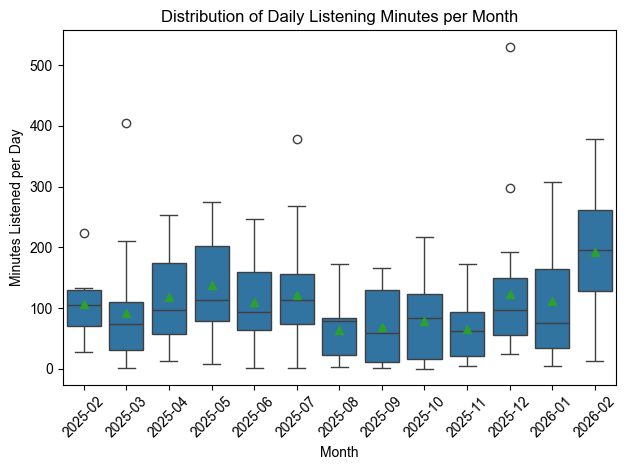

In [25]:
dailytotals = df.groupby(['month', df['endTime'].dt.date])['minutes'].sum().reset_index()
dailytotals.columns = ['Month', 'Date', 'DailyMinutes']
sns.boxplot(x='Month', y='DailyMinutes', data=dailytotals, showmeans=True)
plt.title("Distribution of Daily Listening Minutes per Month")
plt.xlabel("Month")
plt.ylabel("Minutes Listened per Day")
plt.xticks(rotation=45)
plt.tight_layout()

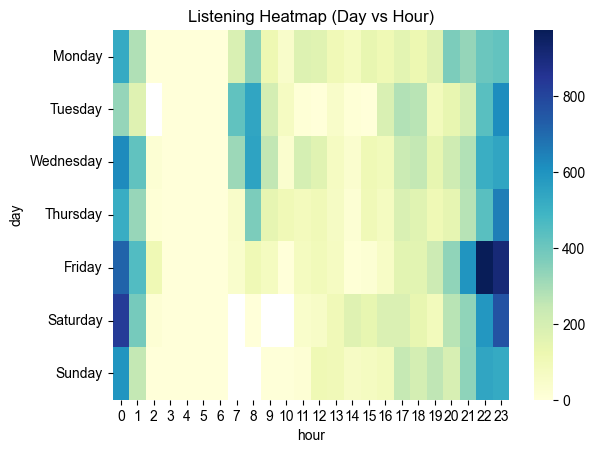

In [26]:
pivot = df.pivot_table(values='minutes', index='day', columns='hour', aggfunc='sum').reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], columns=range(24), fill_value=0)
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Listening Heatmap (Day vs Hour)")
plt.show()

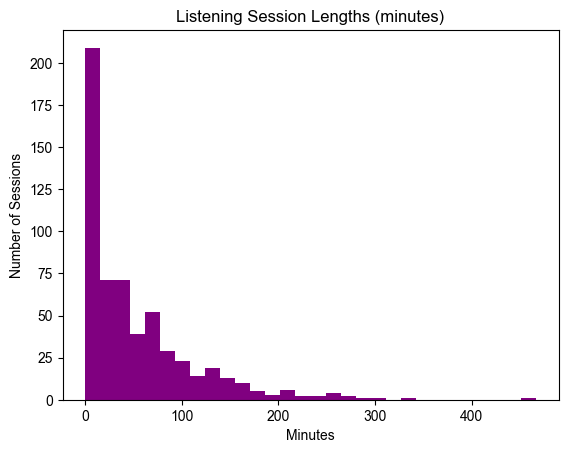

In [27]:
df = df.sort_values('endTime')
df['gap'] = df['endTime'].diff().dt.total_seconds().fillna(0)
df['newsession'] = df['gap'] > 1800
df['sessionid'] = df['newsession'].cumsum()
sessions = df.groupby('sessionid')['minutes'].sum()
plt.hist(sessions, bins=30, color='purple')
plt.title("Listening Session Lengths (minutes)")
plt.xlabel("Minutes")
plt.ylabel("Number of Sessions")
plt.show()

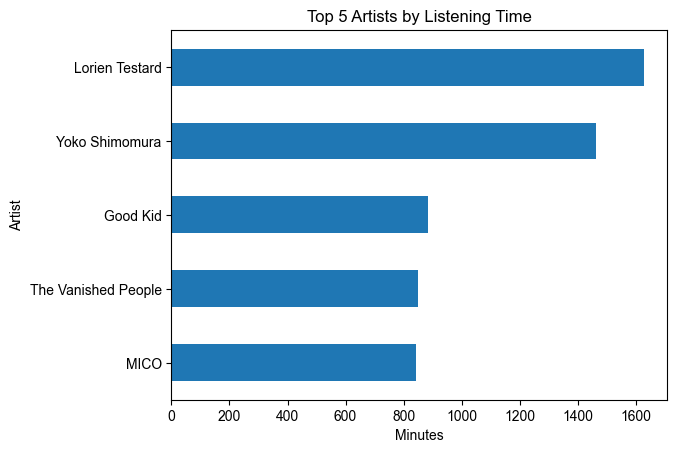

In [28]:
topartists = df.groupby('artistName')['minutes'].sum().sort_values(ascending=False).head(5)
topartists.plot(kind='barh')
plt.title("Top 5 Artists by Listening Time")
plt.xlabel("Minutes")
plt.ylabel("Artist")
plt.gca().invert_yaxis()
plt.show()

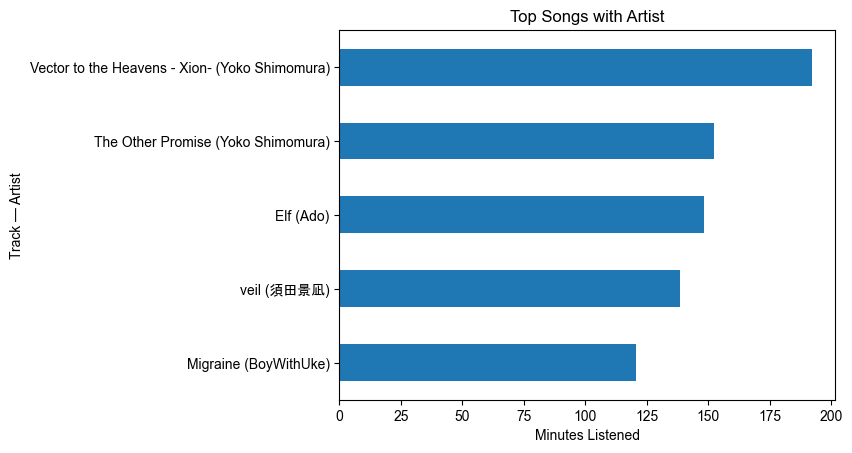

In [29]:
df['trackartist'] = df['trackName'] + " (" + df['artistName'] + ')'
toptracks = df.groupby('trackartist')['minutes'].sum().sort_values(ascending=False).head(5)
toptracks.plot(kind='barh')
plt.title("Top Songs with Artist")
plt.gca().invert_yaxis()
plt.xlabel("Minutes Listened")
plt.ylabel("Track — Artist")
plt.show()

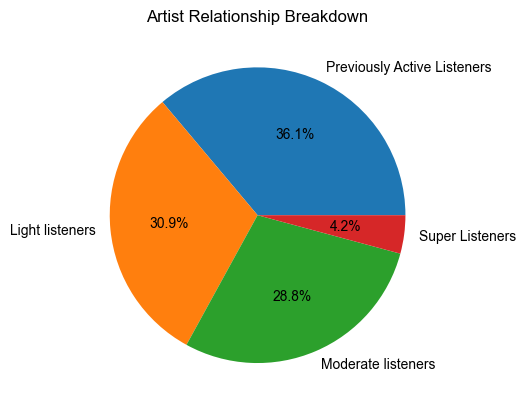

In [30]:
with open('Sriharsha Spotify Account Data/Marquee.json', 'r', encoding='utf-8') as f:
    marqueedf = pd.DataFrame(json.load(f))
marqueedf['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Artist Relationship Breakdown")
plt.ylabel("")
plt.show()

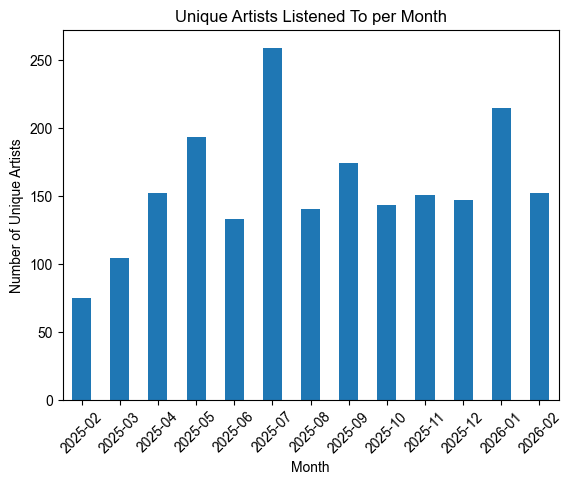

In [31]:
monthlyartists = df.groupby('month')['artistName'].nunique()
monthlyartists.plot(kind='bar')
plt.title("Unique Artists Listened To per Month")
plt.xlabel("Month")
plt.ylabel("Number of Unique Artists")
plt.xticks(rotation=45)
plt.show()

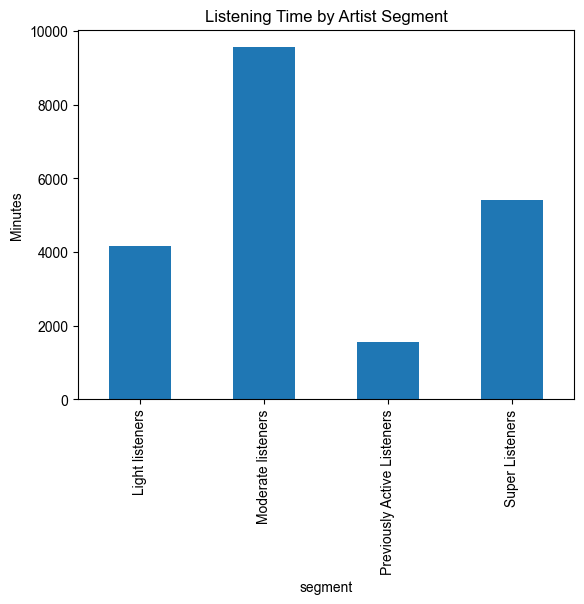

In [32]:
dfmarquee = df.merge(marqueedf[['artistName','segment']], on='artistName', how='left')
dfmarquee.groupby('segment')['minutes'].sum().plot(kind='bar')
plt.title("Listening Time by Artist Segment")
plt.ylabel("Minutes")
plt.show()

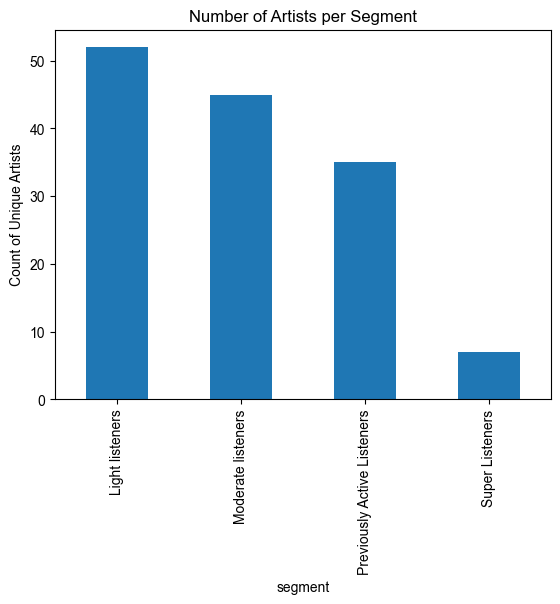

In [33]:
countpersegment = dfmarquee.groupby('segment')['artistName'].nunique()
countpersegment.plot(kind='bar')
plt.title("Number of Artists per Segment")
plt.ylabel("Count of Unique Artists")
plt.show()

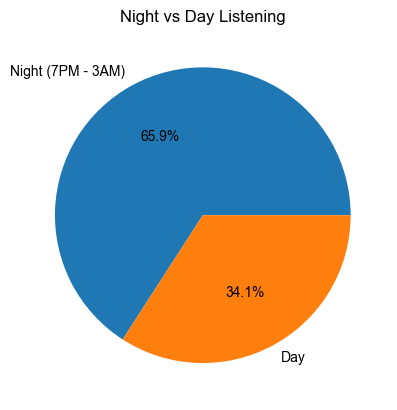

In [34]:
nightminutes = df[(df['hour'] >= 19) | (df['hour'] <= 2)]['minutes'].sum()
dayminutes = df[~((df['hour'] >= 19) | (df['hour'] <= 2))]['minutes'].sum()
plt.figure()
plt.pie([nightminutes, dayminutes], labels=["Night (7PM - 3AM)", "Day"], autopct='%1.1f%%')
plt.title("Night vs Day Listening")
plt.show()